# Phase 1: 문제 상황 분석
## 2025 국민독서실태조사 (초중고 학생) 데이터 분석

**목적:** 학생들의 독서 현황과 문제점을 데이터로 증명하여 BookPath 서비스의 필요성을 뒷받침한다.

**분석 항목:**
1. Q6 독서의 도움 정도 — 학생들이 독서의 가치를 인식하는가?
2. Q6-1 독서의 유용성 — 독서가 무엇에 도움된다고 생각하는가?
3. Q14 도서 선호 분야 — 어떤 분야의 책을 주로 읽는가?
4. Q15 도서 선택 시 이용 정보 — 책을 어떻게 선택하는가?
5. Q34-1 학교에 바라는 점 — 독서 환경에서 무엇을 원하는가?

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import os

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 150

# 경로 설정
DATA_PATH = '../2025 국민독서실태조사. 학생.xlsx'
GRAPH_DIR = 'graphs'
os.makedirs(GRAPH_DIR, exist_ok=True)

# 색상 팔레트
COLORS_MAIN = ['#2563EB', '#3B82F6', '#93C5FD', '#BFDBFE', '#DBEAFE']
COLORS_SCHOOL = ['#F59E0B', '#10B981', '#3B82F6']  # 초등/중학/고등
ACCENT = '#2563EB'

# 데이터 로드
df = pd.read_excel(DATA_PATH, sheet_name='Sheet1', header=None)
print(f'데이터 로드 완료: {df.shape[0]} 행 × {df.shape[1]} 열')

데이터 로드 완료: 8474 행 × 19 열


---
## 1. Q6 독서의 도움 정도
학생들이 독서가 자신에게 얼마나 도움이 된다고 느끼는지 측정.

In [2]:
# Q6 데이터 추출 (행 556)
# 컬럼 헤더: 행 557, 전체: 행 559, 학교급: 행 560-562

q6_headers = [str(df.iloc[557, c]) for c in range(3, 8)]
q6_headers = [h.replace('①', '').replace('②', '').replace('③', '').replace('④', '').replace('⑤', '').strip() for h in q6_headers]

# 전체 + 학교급별
labels_school = ['전체', '초등학교', '중학교', '고등학교']
rows_school = [559, 560, 561, 562]

q6_data = {}
for label, row in zip(labels_school, rows_school):
    q6_data[label] = [float(df.iloc[row, c]) for c in range(3, 8)]

print('Q6 응답 항목:', q6_headers)
print('전체:', [f'{v:.1f}%' for v in q6_data['전체']])

Q6 응답 항목: ['매우 도움이 된다', '어느 정도 도움이 된다', '보통이다', '별로 도움이 되지 않는다', '전혀 도움이 되지 않는다']
전체: ['36.7%', '41.1%', '15.9%', '5.5%', '0.7%']


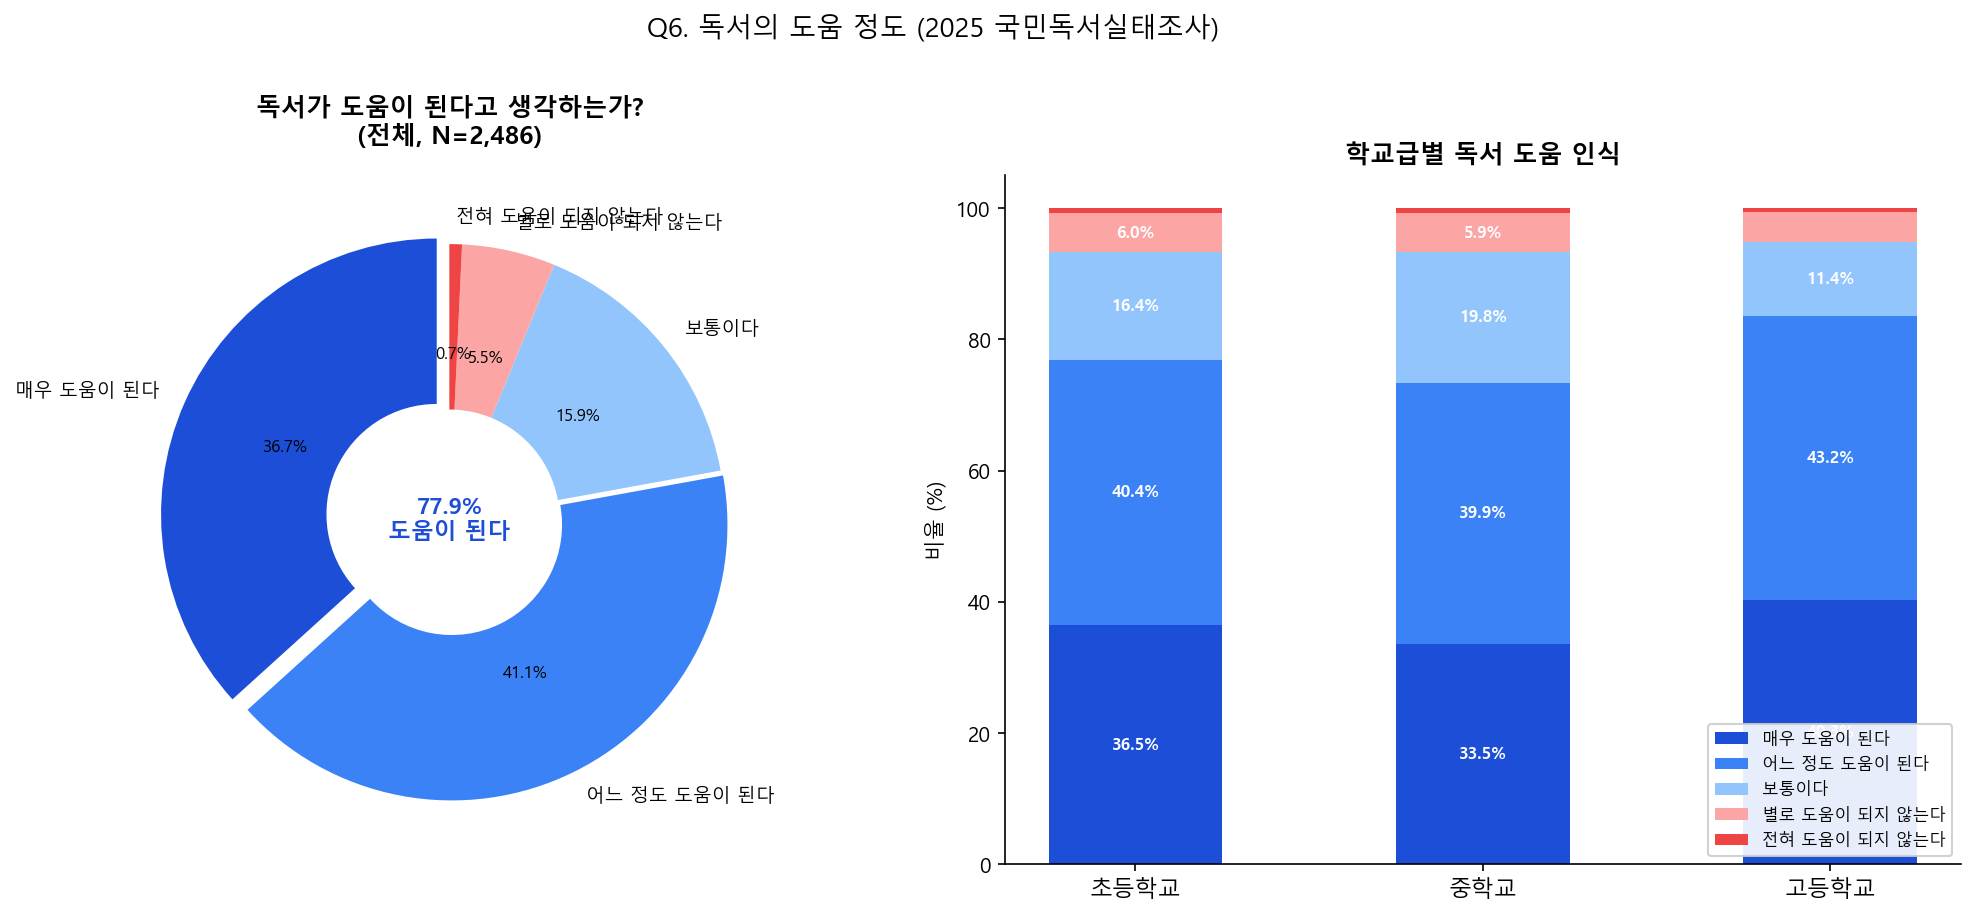

저장: graphs/q6_reading_helpfulness.png


In [3]:
# Q6 차트 1: 전체 파이 차트
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 왼쪽: 전체 도넛 차트
ax1 = axes[0]
wedge_colors = ['#1D4ED8', '#3B82F6', '#93C5FD', '#FCA5A5', '#EF4444']
explode = (0.05, 0.02, 0, 0, 0)
wedges, texts, autotexts = ax1.pie(
    q6_data['전체'],
    labels=q6_headers,
    autopct='%1.1f%%',
    colors=wedge_colors,
    explode=explode,
    startangle=90,
    wedgeprops=dict(width=0.6),
    textprops={'fontsize': 9}
)
for at in autotexts:
    at.set_fontsize(8)
ax1.set_title('독서가 도움이 된다고 생각하는가?\n(전체, N=2,486)', fontsize=12, fontweight='bold', pad=15)

# 도움 된다 합계 텍스트
helpful_pct = q6_data['전체'][0] + q6_data['전체'][1]
ax1.text(0, 0, f'{helpful_pct:.1f}%\n도움이 된다', ha='center', va='center',
         fontsize=11, fontweight='bold', color='#1D4ED8')

# 오른쪽: 학교급별 누적 막대 그래프
ax2 = axes[1]
school_labels = ['초등학교', '중학교', '고등학교']
x = np.arange(len(school_labels))
bar_colors = ['#1D4ED8', '#3B82F6', '#93C5FD', '#FCA5A5', '#EF4444']

bottoms = np.zeros(3)
for i, (header, color) in enumerate(zip(q6_headers, bar_colors)):
    values = [q6_data[s][i] for s in school_labels]
    bars = ax2.bar(x, values, bottom=bottoms, color=color, label=header, width=0.5)
    # 값 레이블 (작은 경우 생략)
    for j, (bar, v) in enumerate(zip(bars, values)):
        if v > 5:
            ax2.text(bar.get_x() + bar.get_width()/2, bottoms[j] + v/2,
                     f'{v:.1f}%', ha='center', va='center', fontsize=8, color='white', fontweight='bold')
    bottoms += np.array(values)

ax2.set_xticks(x)
ax2.set_xticklabels(school_labels, fontsize=11)
ax2.set_ylabel('비율 (%)')
ax2.set_ylim(0, 105)
ax2.set_title('학교급별 독서 도움 인식', fontsize=12, fontweight='bold')
ax2.legend(loc='lower right', fontsize=8, framealpha=0.9)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.suptitle('Q6. 독서의 도움 정도 (2025 국민독서실태조사)', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(f'{GRAPH_DIR}/q6_reading_helpfulness.png', bbox_inches='tight', dpi=150)
plt.show()
print(f'저장: {GRAPH_DIR}/q6_reading_helpfulness.png')

---
## 2. Q6-1 독서의 유용성 (1순위)
학생들이 독서가 어떤 면에서 가장 도움이 된다고 생각하는지 분석.

In [4]:
# Q6-1 데이터 추출 (행 626)
# 컬럼 헤더: 행 627, 전체: 행 629, 학교급: 행 630-632

# 컬럼 수 확인
q61_raw_headers = [str(df.iloc[627, c]) for c in range(3, 13)]
q61_headers = [h for h in q61_raw_headers if h != 'nan']

# 헤더 단축
q61_short = [
    '정보 해석 능력',
    '표현력·창의력',
    '전문 지식 축적',
    '논리적 사고',
    '정서·감성 발달',
    '세상 통찰력',
    '의사소통 향상',
    '행복감·삶의 질',
    '마음 위로'
]

labels_school = ['전체', '초등학교', '중학교', '고등학교']
rows_q61 = [629, 630, 631, 632]

q61_data = {}
for label, row in zip(labels_school, rows_q61):
    vals = []
    for c in range(3, 3+len(q61_short)):
        v = df.iloc[row, c]
        vals.append(float(v) if str(v) != 'nan' else 0.0)
    q61_data[label] = vals

print('전체 유용성 1순위 top5:')
sorted_idx = sorted(range(len(q61_data['전체'])), key=lambda i: q61_data['전체'][i], reverse=True)
for i in sorted_idx[:5]:
    print(f'  {q61_short[i]}: {q61_data["전체"][i]:.1f}%')

전체 유용성 1순위 top5:
  정보 해석 능력: 38.4%
  표현력·창의력: 14.1%
  전문 지식 축적: 11.4%
  논리적 사고: 8.4%
  정서·감성 발달: 6.8%


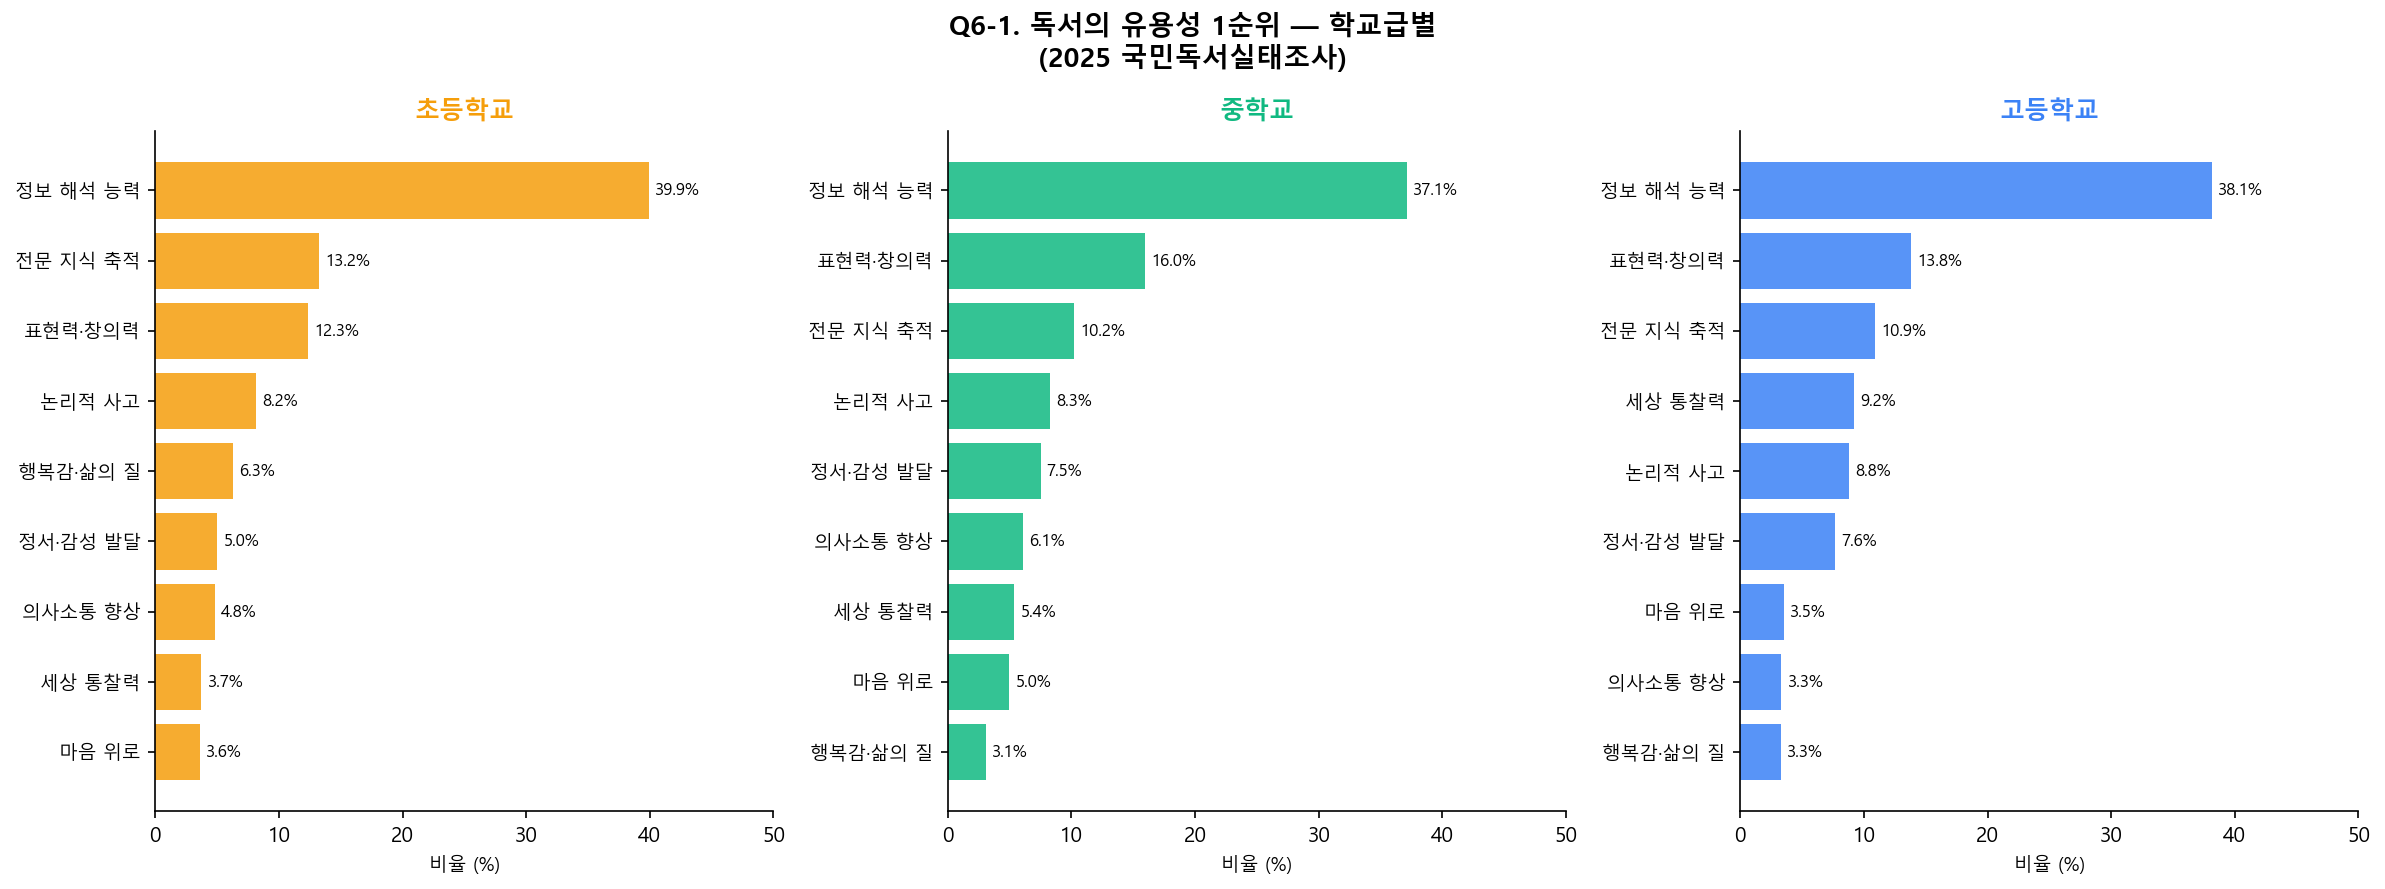

저장: graphs/q6_1_reading_utility.png


In [5]:
# Q6-1 차트: 학교급별 가로 막대 그래프
fig, axes = plt.subplots(1, 3, figsize=(16, 6), sharey=False)

school_colors = ['#F59E0B', '#10B981', '#3B82F6']
schools = ['초등학교', '중학교', '고등학교']

for ax, school, color in zip(axes, schools, school_colors):
    vals = q61_data[school]
    sorted_pairs = sorted(zip(vals, q61_short), reverse=True)
    sorted_vals, sorted_labels = zip(*sorted_pairs)
    
    y = np.arange(len(sorted_labels))
    bars = ax.barh(y, sorted_vals, color=color, alpha=0.85)
    
    ax.set_yticks(y)
    ax.set_yticklabels(sorted_labels, fontsize=9)
    ax.set_xlabel('비율 (%)', fontsize=9)
    ax.set_title(school, fontsize=12, fontweight='bold', color=color)
    ax.set_xlim(0, 50)
    
    for bar, val in zip(bars, sorted_vals):
        ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                f'{val:.1f}%', va='center', fontsize=8)
    
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.invert_yaxis()

plt.suptitle('Q6-1. 독서의 유용성 1순위 — 학교급별\n(2025 국민독서실태조사)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{GRAPH_DIR}/q6_1_reading_utility.png', bbox_inches='tight', dpi=150)
plt.show()
print(f'저장: {GRAPH_DIR}/q6_1_reading_utility.png')

---
## 3. Q14 도서 선호 분야 (종이책, 1순위)
학생들이 어떤 분야의 책을 가장 많이 읽는지 — BookPath의 KDC 분류와 직접 연결.

In [6]:
# Q14 데이터 추출 (행 3587)
# 컬럼 헤더: 행 3588, 전체: 행 3590, 학교급: 행 3591-3593

q14_raw_headers = [str(df.iloc[3588, c]) for c in range(3, 16)]
q14_headers = [h for h in q14_raw_headers if h != 'nan']

# 헤더 단축
q14_short = [
    '소설·동화',
    '그림책',
    '취미·오락·여행',
    '과학·기술·컴퓨터',
    '동시·시',
    '역사·지리',
    '자기계발',
    '경제·경영',
    '철학·사상·종교',
    '수필',
    '정치·사회·시사'
]

labels_school = ['전체', '초등학교', '중학교', '고등학교']
rows_q14 = [3590, 3591, 3592, 3593]

q14_data = {}
for label, row in zip(labels_school, rows_q14):
    vals = []
    for c in range(3, 3+len(q14_short)):
        v = df.iloc[row, c]
        vals.append(float(v) if str(v) != 'nan' else 0.0)
    q14_data[label] = vals

print('전체 선호 분야 top5:')
sorted_idx = sorted(range(len(q14_data['전체'])), key=lambda i: q14_data['전체'][i], reverse=True)
for i in sorted_idx[:5]:
    print(f'  {q14_short[i]}: {q14_data["전체"][i]:.1f}%')

전체 선호 분야 top5:
  소설·동화: 45.5%
  그림책: 10.9%
  취미·오락·여행: 9.5%
  과학·기술·컴퓨터: 9.0%
  동시·시: 6.5%


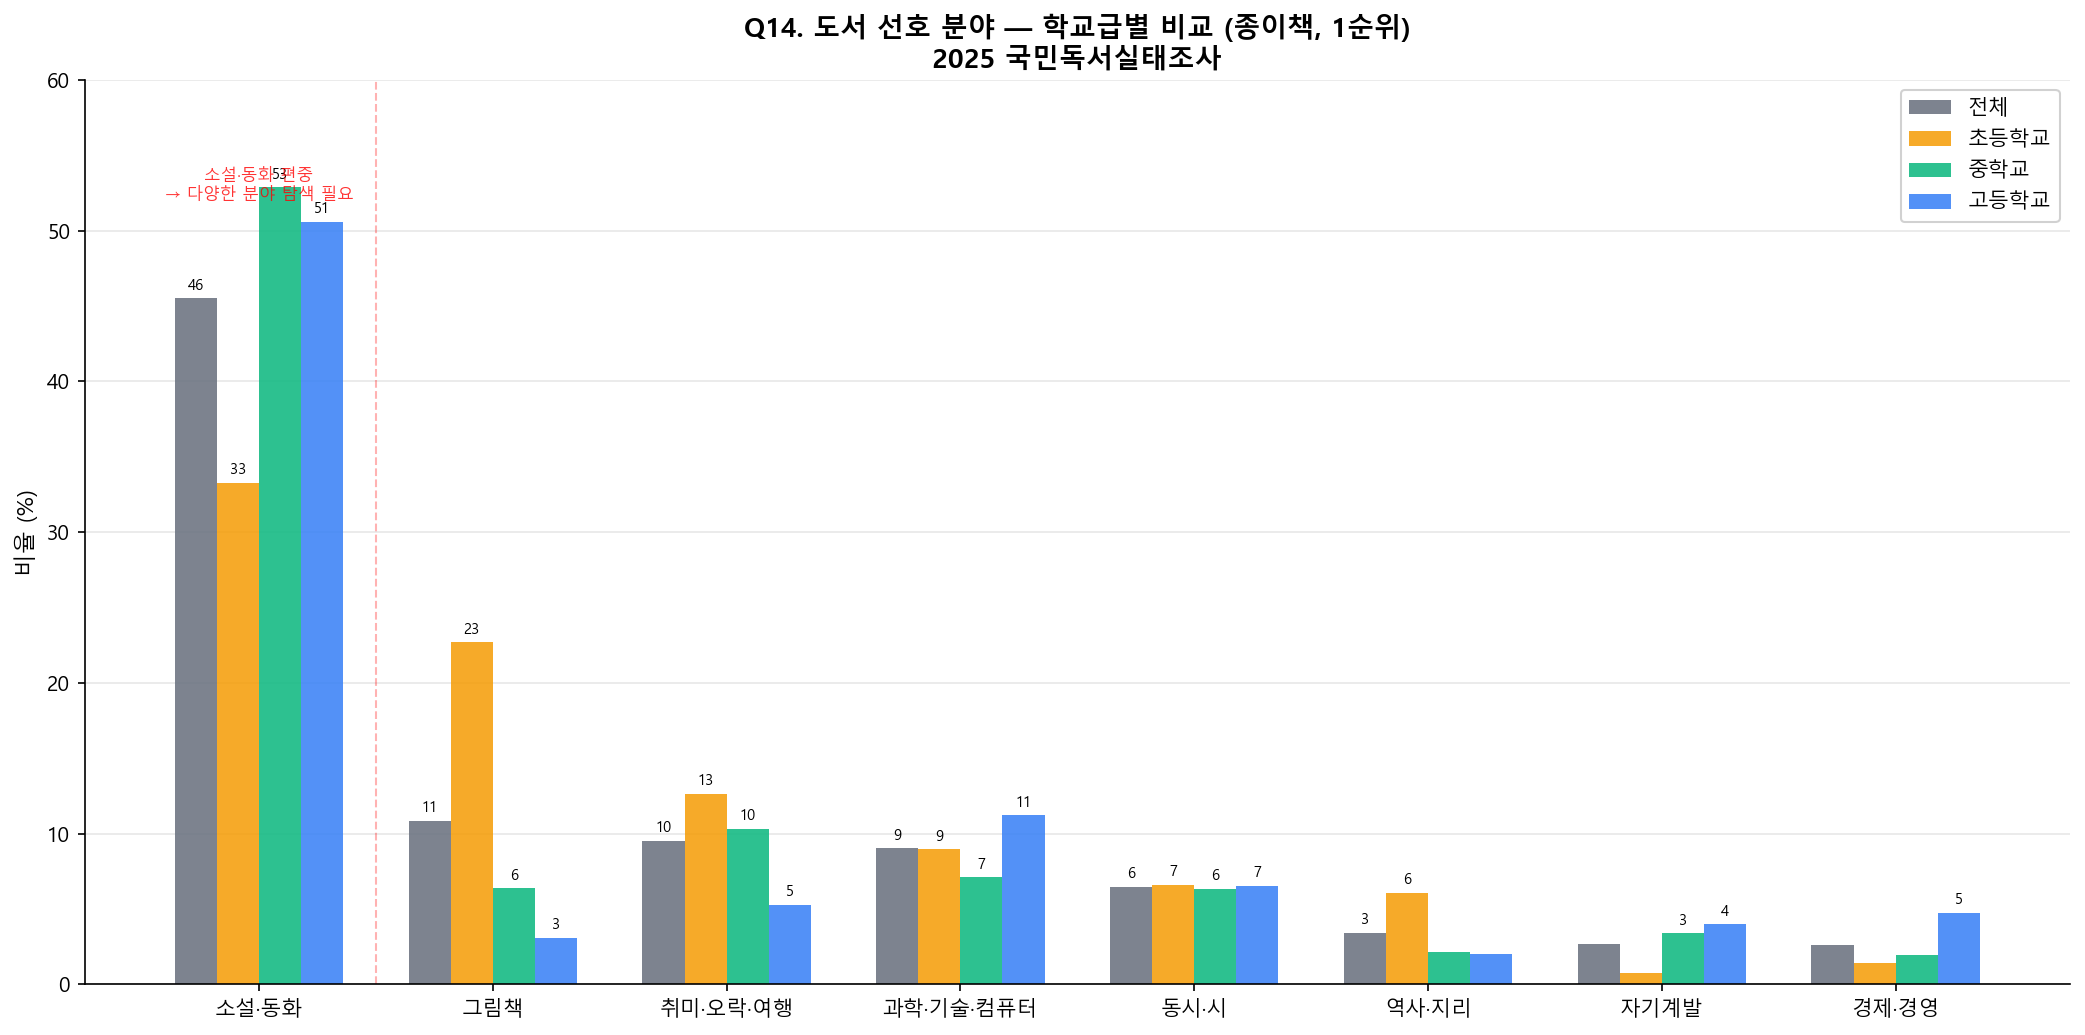

저장: graphs/q14_book_genre_preference.png


In [7]:
# Q14 차트: 학교급별 그룹 막대 그래프 (상위 8개 분야)
fig, ax = plt.subplots(figsize=(14, 7))

# 전체 기준으로 정렬 후 상위 8개 선택
sorted_idx = sorted(range(len(q14_data['전체'])), key=lambda i: q14_data['전체'][i], reverse=True)[:8]
top8_labels = [q14_short[i] for i in sorted_idx]

schools = ['전체', '초등학교', '중학교', '고등학교']
bar_colors = ['#6B7280', '#F59E0B', '#10B981', '#3B82F6']

n_groups = len(top8_labels)
n_bars = len(schools)
x = np.arange(n_groups)
bar_width = 0.18

for i, (school, color) in enumerate(zip(schools, bar_colors)):
    vals = [q14_data[school][j] for j in sorted_idx]
    offset = (i - n_bars/2 + 0.5) * bar_width
    bars = ax.bar(x + offset, vals, width=bar_width, label=school, color=color, alpha=0.88)
    for bar, val in zip(bars, vals):
        if val >= 3:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                    f'{val:.0f}', ha='center', va='bottom', fontsize=7)

ax.set_xticks(x)
ax.set_xticklabels(top8_labels, fontsize=10)
ax.set_ylabel('비율 (%)', fontsize=11)
ax.set_ylim(0, 60)
ax.set_title('Q14. 도서 선호 분야 — 학교급별 비교 (종이책, 1순위)\n2025 국민독서실태조사', fontsize=13, fontweight='bold')
ax.legend(fontsize=10, framealpha=0.9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.yaxis.grid(True, alpha=0.3)
ax.set_axisbelow(True)

# 소설·동화 편중 강조
ax.axvline(x=0.5, color='red', linestyle='--', alpha=0.3, linewidth=1)
ax.text(0, 52, '소설·동화 편중\n→ 다양한 분야 탐색 필요', ha='center', fontsize=8, color='red', alpha=0.8)

plt.tight_layout()
plt.savefig(f'{GRAPH_DIR}/q14_book_genre_preference.png', bbox_inches='tight', dpi=150)
plt.show()
print(f'저장: {GRAPH_DIR}/q14_book_genre_preference.png')

---
## 4. Q15 도서 선택 시 이용 정보 (1순위)
학생들이 어떤 경로로 책을 선택하는가 — 서점/도서관에서 직접 보는 비율 vs. 추천 기반

In [8]:
# Q15 데이터 추출 (행 3965)
# 컬럼 헤더: 행 3966, 전체: 행 3968, 학교급: 행 3969-3971

q15_raw_headers = [str(df.iloc[3966, c]) for c in range(3, 12)]
q15_headers_full = [h for h in q15_raw_headers if h != 'nan']

q15_short = [
    '서점·도서관서 직접',
    'SNS·인터넷 소개',
    '학교 추천',
    '주변 사람 추천',
    '유튜브·팟캐스트',
    '베스트셀러',
    '드라마·영화 원작',
    '기타',
    '신문·방송 소개'
]

labels_school = ['전체', '초등학교', '중학교', '고등학교']
rows_q15 = [3968, 3969, 3970, 3971]

q15_data = {}
for label, row in zip(labels_school, rows_q15):
    vals = []
    for c in range(3, 3+len(q15_short)):
        v = df.iloc[row, c]
        vals.append(float(v) if str(v) != 'nan' else 0.0)
    q15_data[label] = vals

print('전체 도서 선택 경로 top5:')
sorted_idx = sorted(range(len(q15_data['전체'])), key=lambda i: q15_data['전체'][i], reverse=True)
for i in sorted_idx[:5]:
    print(f'  {q15_short[i]}: {q15_data["전체"][i]:.1f}%')

전체 도서 선택 경로 top5:
  서점·도서관서 직접: 41.6%
  SNS·인터넷 소개: 20.2%
  학교 추천: 10.5%
  주변 사람 추천: 7.3%
  유튜브·팟캐스트: 6.7%


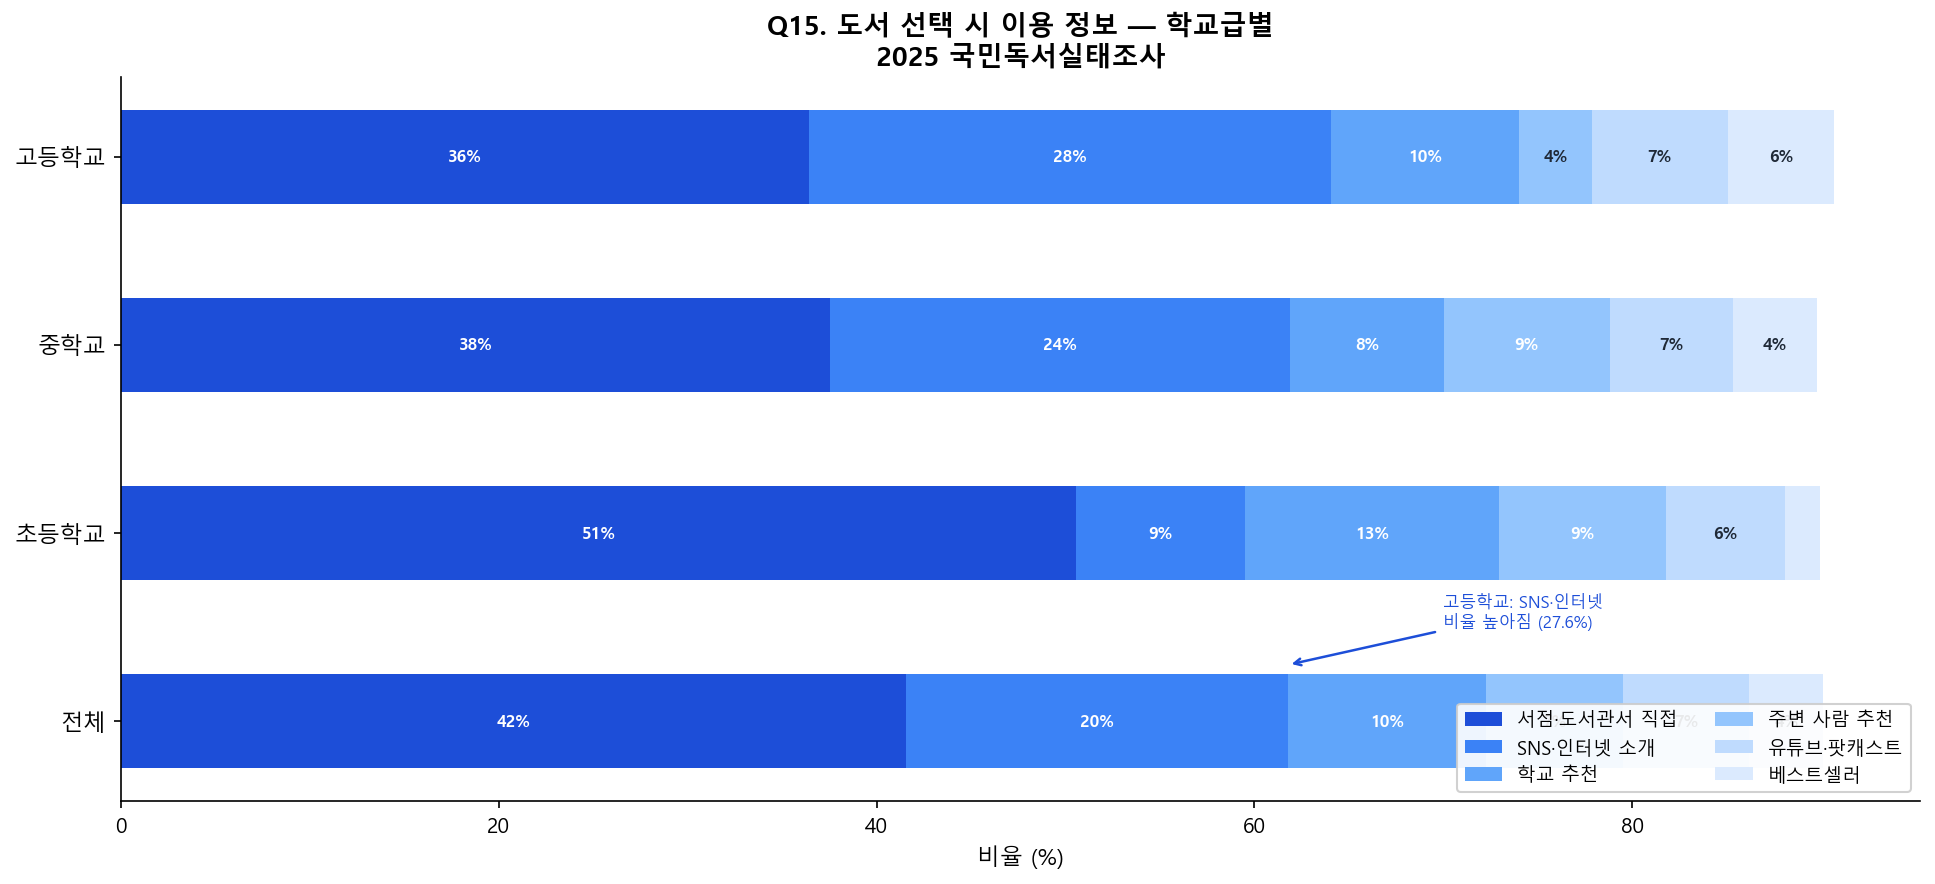

저장: graphs/q15_book_selection_method.png


In [9]:
# Q15 차트: 학교급별 수평 누적 막대 (전체 경로 비교)
fig, ax = plt.subplots(figsize=(13, 6))

schools = ['전체', '초등학교', '중학교', '고등학교']
# 상위 6개만
sorted_idx_all = sorted(range(len(q15_data['전체'])), key=lambda i: q15_data['전체'][i], reverse=True)[:6]
top6_labels = [q15_short[i] for i in sorted_idx_all]

palette = ['#1D4ED8', '#3B82F6', '#60A5FA', '#93C5FD', '#BFDBFE', '#DBEAFE']

y = np.arange(len(schools))
lefts = np.zeros(len(schools))

for i, (label, color) in enumerate(zip(top6_labels, palette)):
    idx = sorted_idx_all[i]
    vals = [q15_data[s][idx] for s in schools]
    bars = ax.barh(y, vals, left=lefts, color=color, label=label, height=0.5)
    for j, (bar, val) in enumerate(zip(bars, vals)):
        if val > 3:
            ax.text(lefts[j] + val/2, bar.get_y() + bar.get_height()/2,
                    f'{val:.0f}%', ha='center', va='center', fontsize=8,
                    color='white' if val > 8 else '#1F2937', fontweight='bold')
    lefts += np.array(vals)

ax.set_yticks(y)
ax.set_yticklabels(schools, fontsize=11)
ax.set_xlabel('비율 (%)', fontsize=11)
ax.set_title('Q15. 도서 선택 시 이용 정보 — 학교급별\n2025 국민독서실태조사', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=9, framealpha=0.9, ncol=2)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# 고등학생의 SNS 비율 높음 주석
ax.annotate('고등학교: SNS·인터넷\n비율 높아짐 (27.6%)',
             xy=(41.55 + 20.2, 0.3), xytext=(70, 0.5),
             fontsize=8, color='#1D4ED8',
             arrowprops=dict(arrowstyle='->', color='#1D4ED8', lw=1.2))

plt.tight_layout()
plt.savefig(f'{GRAPH_DIR}/q15_book_selection_method.png', bbox_inches='tight', dpi=150)
plt.show()
print(f'저장: {GRAPH_DIR}/q15_book_selection_method.png')

---
## 5. Q34-1 학교에 바라는 점 (1순위)
학생들이 학교 독서 환경에서 가장 원하는 것은 무엇인가 — BookPath가 해결할 수 있는 니즈 확인

In [10]:
# Q34-1 데이터 추출 (행 8195)
# 컬럼 헤더: 행 8196, 전체: 행 8198, 학교급: 행 8199-8201

q34_raw_headers = [str(df.iloc[8196, c]) for c in range(3, 9)]
q34_headers_full = [h for h in q34_raw_headers if h != 'nan']

q34_short = [
    '내 관심에 맞는\n책 소개',
    '도서관 편하게\n이용',
    '교실 학급문고\n확충',
    '독서 시간\n확대',
    '독서 행사\n다양화',
    '독서 방법\n지도'
]

labels_school = ['전체', '초등학교', '중학교', '고등학교']
rows_q34 = [8198, 8199, 8200, 8201]

q34_data = {}
for label, row in zip(labels_school, rows_q34):
    vals = []
    for c in range(3, 3+len(q34_short)):
        v = df.iloc[row, c]
        vals.append(float(v) if str(v) != 'nan' else 0.0)
    q34_data[label] = vals

print('전체 학교에 바라는 점:')
for label, val in zip(q34_short, q34_data['전체']):
    print(f'  {label.replace(chr(10)," ")}: {val:.1f}%')

전체 학교에 바라는 점:
  내 관심에 맞는 책 소개: 31.0%
  도서관 편하게 이용: 25.3%
  교실 학급문고 확충: 17.0%
  독서 시간 확대: 15.4%
  독서 행사 다양화: 8.0%
  독서 방법 지도: 3.3%


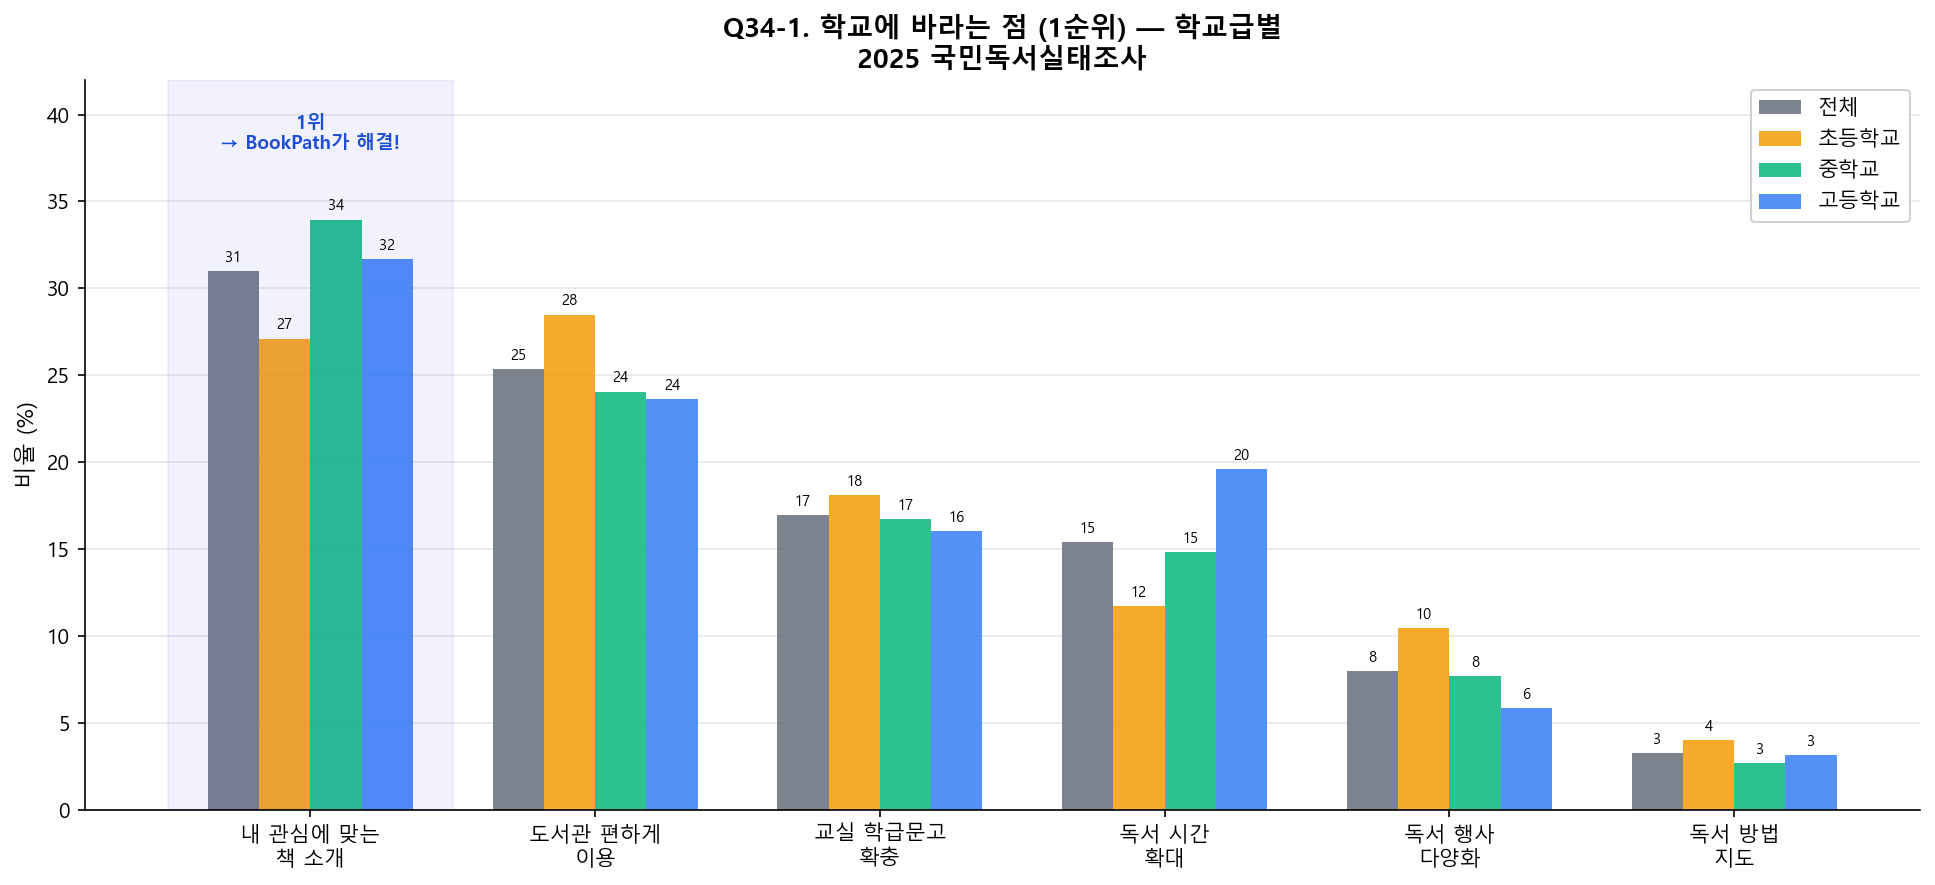

저장: graphs/q34_school_reading_wishes.png


In [11]:
# Q34-1 차트: 학교급별 그룹 막대
fig, ax = plt.subplots(figsize=(13, 6))

schools = ['전체', '초등학교', '중학교', '고등학교']
bar_colors = ['#6B7280', '#F59E0B', '#10B981', '#3B82F6']

n_groups = len(q34_short)
n_bars = len(schools)
x = np.arange(n_groups)
bar_width = 0.18

for i, (school, color) in enumerate(zip(schools, bar_colors)):
    vals = q34_data[school]
    offset = (i - n_bars/2 + 0.5) * bar_width
    bars = ax.bar(x + offset, vals, width=bar_width, label=school, color=color, alpha=0.88)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f'{val:.0f}', ha='center', va='bottom', fontsize=7)

ax.set_xticks(x)
ax.set_xticklabels(q34_short, fontsize=10)
ax.set_ylabel('비율 (%)', fontsize=11)
ax.set_ylim(0, 42)
ax.set_title('Q34-1. 학교에 바라는 점 (1순위) — 학교급별\n2025 국민독서실태조사', fontsize=13, fontweight='bold')
ax.legend(fontsize=10, framealpha=0.9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.yaxis.grid(True, alpha=0.3)
ax.set_axisbelow(True)

# 1위 항목 강조
ax.axvspan(-0.5, 0.5, alpha=0.05, color='blue')
ax.text(0, 38, '1위\n→ BookPath가 해결!', ha='center', fontsize=9,
        color='#1D4ED8', fontweight='bold')

plt.tight_layout()
plt.savefig(f'{GRAPH_DIR}/q34_school_reading_wishes.png', bbox_inches='tight', dpi=150)
plt.show()
print(f'저장: {GRAPH_DIR}/q34_school_reading_wishes.png')

---
## 6. 핵심 인사이트 요약

### BookPath의 필요성을 뒷받침하는 데이터 근거

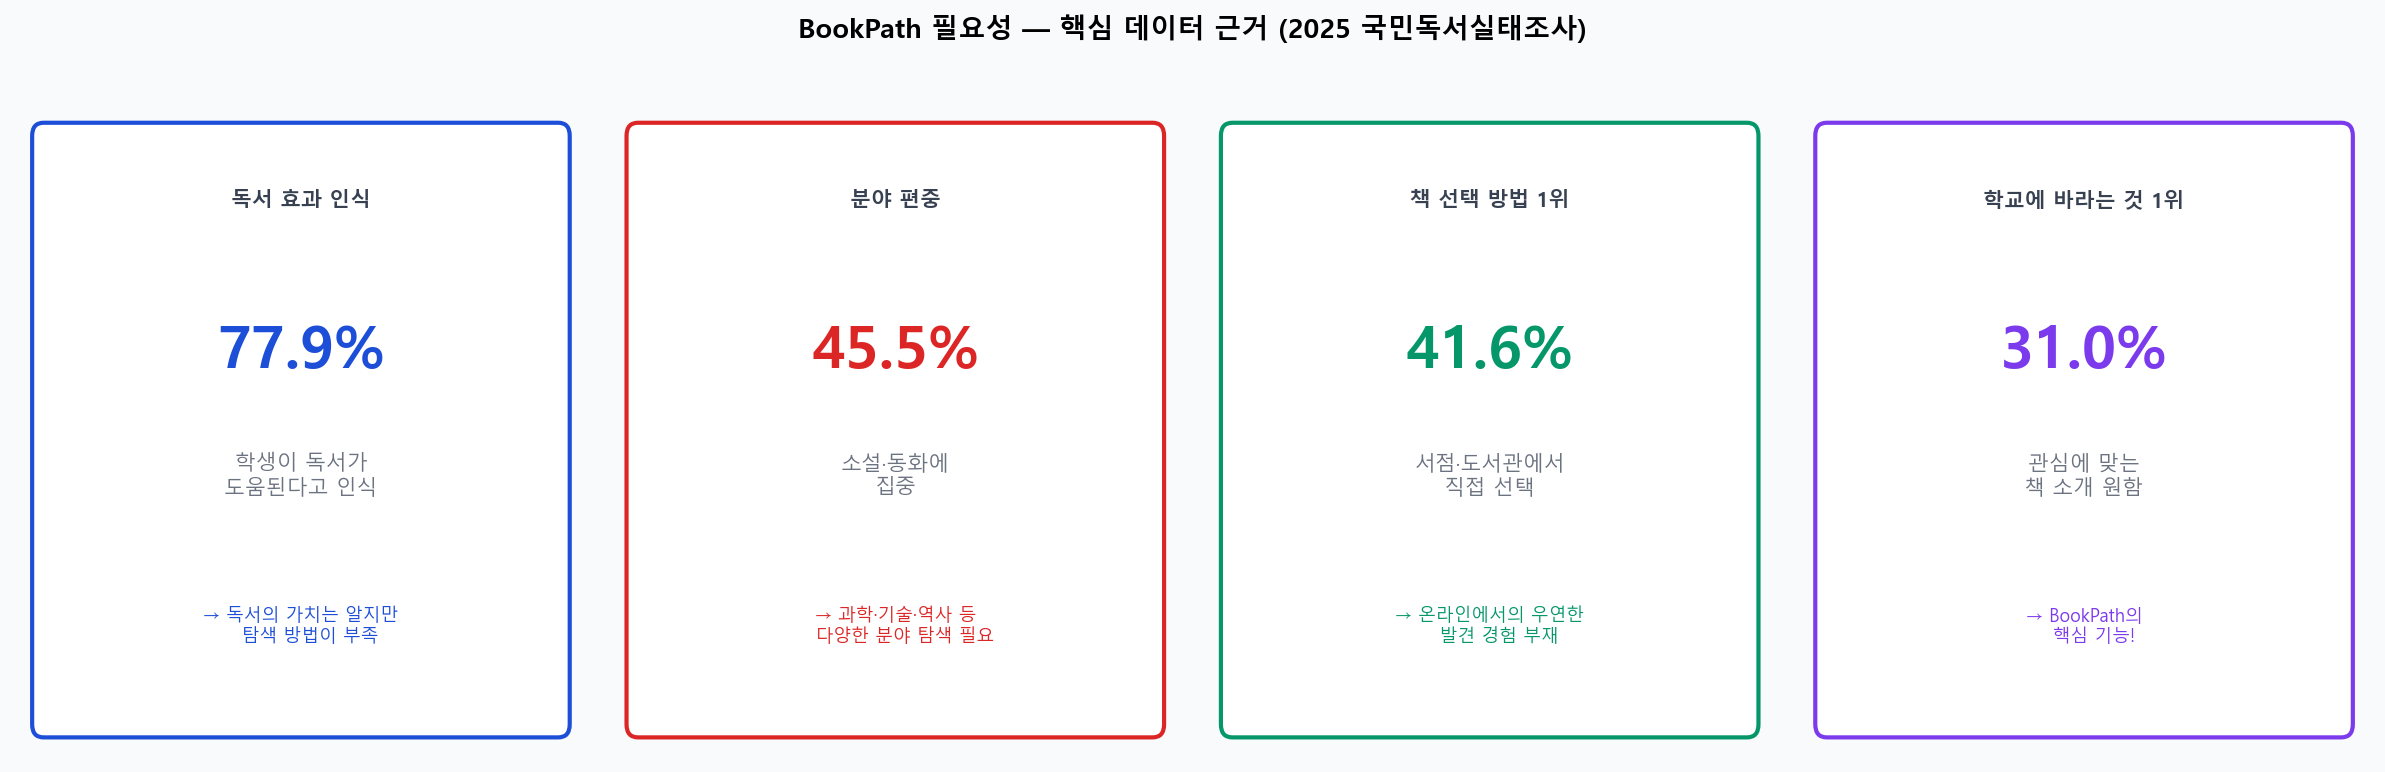

저장: graphs/summary_insight.png


In [12]:
# 요약 인포그래픽
fig, axes = plt.subplots(1, 4, figsize=(16, 5))
fig.patch.set_facecolor('#F8FAFC')

insights = [
    {
        'title': '독서 효과 인식',
        'value': f"{q6_data['전체'][0] + q6_data['전체'][1]:.1f}%",
        'subtitle': '학생이 독서가\n도움된다고 인식',
        'color': '#1D4ED8',
        'detail': '→ 독서의 가치는 알지만\n   탐색 방법이 부족'
    },
    {
        'title': '분야 편중',
        'value': f"{q14_data['전체'][0]:.1f}%",
        'subtitle': '소설·동화에\n집중',
        'color': '#DC2626',
        'detail': '→ 과학·기술·역사 등\n   다양한 분야 탐색 필요'
    },
    {
        'title': '책 선택 방법 1위',
        'value': f"{q15_data['전체'][0]:.1f}%",
        'subtitle': '서점·도서관에서\n직접 선택',
        'color': '#059669',
        'detail': '→ 온라인에서의 우연한\n   발견 경험 부재'
    },
    {
        'title': '학교에 바라는 것 1위',
        'value': f"{q34_data['전체'][0]:.1f}%",
        'subtitle': '관심에 맞는\n책 소개 원함',
        'color': '#7C3AED',
        'detail': '→ BookPath의\n   핵심 기능!'
    }
]

for ax, ins in zip(axes, insights):
    ax.set_facecolor('white')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis('off')
    
    # 배경 박스
    rect = mpatches.FancyBboxPatch((0.05, 0.05), 0.9, 0.9,
                                    boxstyle='round,pad=0.02',
                                    facecolor='white', edgecolor=ins['color'],
                                    linewidth=2)
    ax.add_patch(rect)
    
    ax.text(0.5, 0.85, ins['title'], ha='center', va='center',
            fontsize=10, color='#374151', fontweight='bold')
    ax.text(0.5, 0.62, ins['value'], ha='center', va='center',
            fontsize=28, color=ins['color'], fontweight='bold')
    ax.text(0.5, 0.43, ins['subtitle'], ha='center', va='center',
            fontsize=10, color='#6B7280')
    ax.text(0.5, 0.20, ins['detail'], ha='center', va='center',
            fontsize=8.5, color=ins['color'], style='italic')

plt.suptitle('BookPath 필요성 — 핵심 데이터 근거 (2025 국민독서실태조사)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{GRAPH_DIR}/summary_insight.png', bbox_inches='tight', dpi=150, facecolor='#F8FAFC')
plt.show()
print(f'저장: {GRAPH_DIR}/summary_insight.png')

In [13]:
# 최종 저장 확인
import os
graphs = os.listdir(GRAPH_DIR)
print('생성된 그래프 파일:')
for g in sorted(graphs):
    size = os.path.getsize(f'{GRAPH_DIR}/{g}') // 1024
    print(f'  {g} ({size} KB)')

생성된 그래프 파일:
  q14_book_genre_preference.png (62 KB)
  q15_book_selection_method.png (67 KB)
  q34_school_reading_wishes.png (58 KB)
  q6_1_reading_utility.png (85 KB)
  q6_reading_helpfulness.png (104 KB)
  summary_insight.png (88 KB)
